In [10]:

# 🧬 Case 2: Tumor Misclassification (Breast Cancer Dataset)
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 0 = malignant, 1 = benign

# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [11]:

# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

# Run prediction
pred = model_bc.predict(focus_instance_bc)
print("Prediction for Patient X:", "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed")

     

Prediction for Patient X: Benign → No Biopsy


## EDA ##

In [12]:
df_bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [13]:
print("Full dataset class counts (0=malignant, 1=benign):")
print(y.value_counts())
print("Full dataset benign fraction:", y.mean())
print()
print("Training set class counts:")
print(y_train.value_counts())
print("Training set benign fraction:", y_train.mean())
print()
print("Test set benign fraction:", y_test.mean())

Full dataset class counts (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64
Full dataset benign fraction: 0.6274165202108963

Training set class counts:
target
1    286
0    169
Name: count, dtype: int64
Training set benign fraction: 0.6285714285714286

Test set benign fraction: 0.6228070175438597


Top features by Random Forest importance:
worst area              0.153892
worst concave points    0.144663
mean concave points     0.106210
worst radius            0.077987
mean concavity          0.068001
worst perimeter         0.067115
dtype: float64


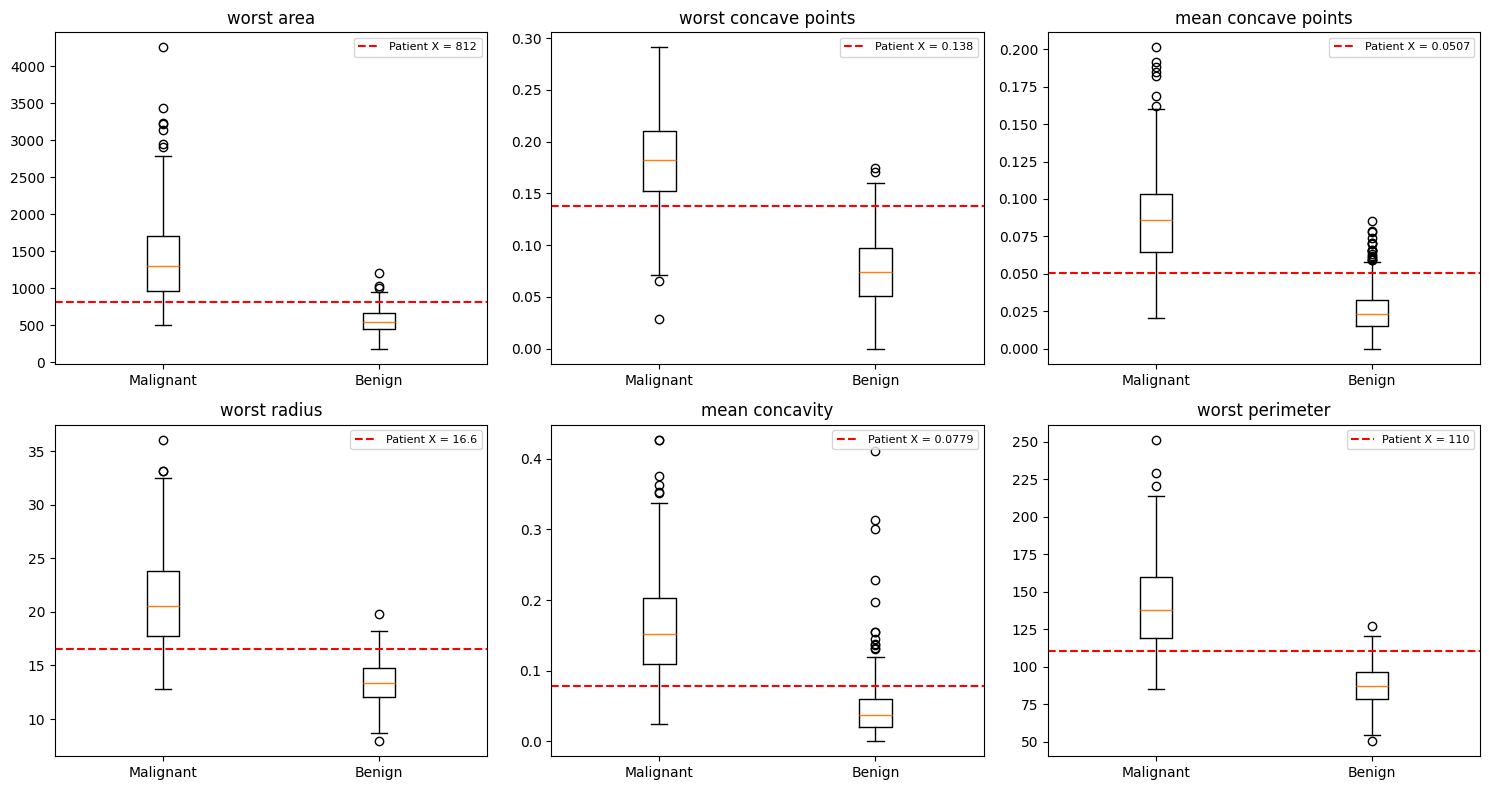

In [14]:
# Compare Patient X against the benign vs. malignant population for the model's most important features
import numpy as np
import matplotlib.pyplot as plt

top_n = 6
importances = pd.Series(model_bc.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
print("Top features by Random Forest importance:")
print(importances.sort_values(ascending=False).head(top_n))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), top_features):
    benign_vals = df_bc.loc[df_bc['target'] == 1, feat]
    malignant_vals = df_bc.loc[df_bc['target'] == 0, feat]
    ax.boxplot([malignant_vals, benign_vals], tick_labels=['Malignant', 'Benign'])
    patient_x_val = focus_instance_bc[feat].iloc[0]
    ax.axhline(patient_x_val, color='red', linestyle='--', label=f'Patient X = {patient_x_val:.3g}')
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## SHAP ##

**How to read this:** SHAP starts from a *base value* (the average predicted probability across the whole training set (here, ~0.63, matching the dataset's 63% benign rate)), and explains Patient X's actual prediction (0.85) as a sum of per-feature contributions that exactly reconcile the two: `base_value + sum(shap_values) = model_output`. Each feature's SHAP value is its fair-share contribution (a Shapley value from cooperative game theory) computed *exactly* for this tree ensemble. Red pushes the prediction toward Benign, blue pushes toward Malignant; bar width = size of the contribution.

In [15]:
import warnings
warnings.filterwarnings('ignore', message='IProgress not found')

import shap

explainer_shap = shap.TreeExplainer(model_bc)

shap_values = explainer_shap.shap_values(focus_instance_bc)

# Plot the explanation for Class 1 (Benign)
shap.initjs()

if isinstance(shap_values, list):
    sv_benign = shap_values[1][0]
    expected_value_benign = explainer_shap.expected_value[1]
else:
    sv_benign = shap_values[0, :, 1]
    expected_value_benign = explainer_shap.expected_value[1]

shap.force_plot(expected_value_benign, sv_benign, focus_instance_bc.iloc[0])

In [16]:
# List every feature as red (pushes toward Benign) or blue (pushes toward Malignant),
# sorted by the size of its SHAP contribution
sv_series = pd.Series(sv_benign, index=focus_instance_bc.columns).sort_values(ascending=False)

print("RED - pushes toward BENIGN (positive SHAP value):")
for feat, val in sv_series[sv_series > 0].items():
    print(f"  {feat:28s} {val:+.4f}")

print()
print("BLUE - pushes toward MALIGNANT (negative SHAP value):")
for feat, val in sv_series[sv_series < 0].sort_values().items():
    print(f"  {feat:28s} {val:+.4f}")


RED - pushes toward BENIGN (positive SHAP value):
  worst texture                +0.0471
  mean concavity               +0.0359
  worst area                   +0.0338
  worst radius                 +0.0288
  mean perimeter               +0.0183
  mean texture                 +0.0174
  mean area                    +0.0163
  worst concave points         +0.0154
  mean radius                  +0.0144
  mean concave points          +0.0130
  worst symmetry               +0.0061
  symmetry error               +0.0059
  worst compactness            +0.0053
  mean compactness             +0.0039
  smoothness error             +0.0034
  texture error                +0.0027
  compactness error            +0.0027
  mean symmetry                +0.0015
  mean fractal dimension       +0.0013
  mean smoothness              +0.0008
  concave points error         +0.0002

BLUE - pushes toward MALIGNANT (negative SHAP value):
  worst perimeter              -0.0227
  worst fractal dimension      -0.010

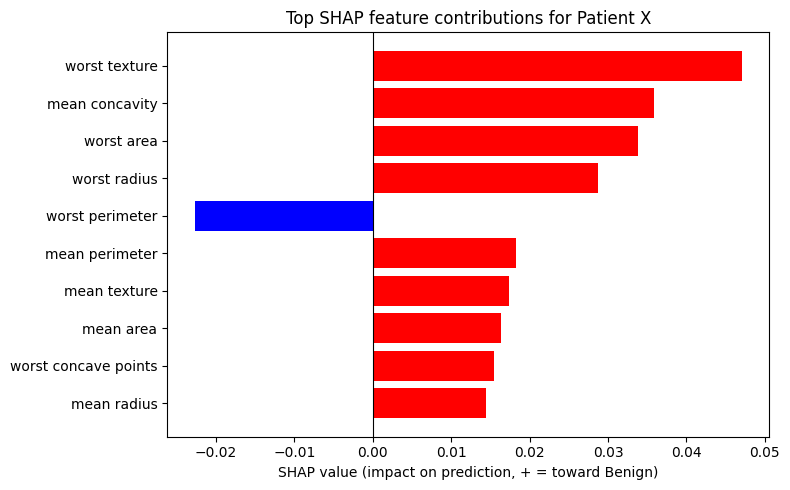

In [17]:
# SHAP feature contributions as a bar chart, styled like the LIME plot below:
# red = pushes toward Benign, blue = pushes toward Malignant, sorted strongest-to-weakest top to bottom
top_n = 10
top_shap = sv_series.reindex(sv_series.abs().sort_values(ascending=False).index).head(top_n)
plot_order = top_shap.iloc[::-1]
colors = ['red' if v > 0 else 'blue' for v in plot_order.values]

plt.figure(figsize=(8, 5))
plt.barh(plot_order.index, plot_order.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('SHAP value (impact on prediction, + = toward Benign)')
plt.title('Top SHAP feature contributions for Patient X')
plt.tight_layout()
plt.show()


From the force plot and. this barplot that showcase the feature contribution, we can see that most of the features are pushing the probability rightward (toward Benign), moving the prediction from the 63% base rate up to 85% confidence that Patient X's tumor is benign.

## LIME ##

**How this works:** unlike SHAP, LIME doesn't try to exactly decompose the real random forest. Instead, it generates thousands of perturbed fake patients near Patient X, gets the real model's predictions for them, and fits a simple weighted linear model to that local neighborhood. The coefficients of that local linear model become the explanation. Because it's only a local approximation (not an exact accounting), LIME's results can shift slightly between runs and can disagree with SHAP on secondary features, but agreement between the two on the top feature (`worst texture`) is a stronger signal than either method alone.

**Reading the bar chart:** each bar is a binned condition on a feature (LIME discretizes continuous features into quartile ranges by default, e.g. `worst texture <= 21.05`). Bar length = how much that condition shifts the predicted probability of the target class in this local neighborhood. Green = supports the predicted class (Benign), red = contradicts it. Bars are ordered strongest-to-weakest from top to bottom.

LIME local explanation for Patient X (feature, weight toward Benign):
  worst texture <= 21.05              +0.0596
  mean texture <= 16.17               +0.0310
  0.10 < worst concave points <= 0.16 +0.0209
  0.25 < worst symmetry <= 0.28       +0.0200
  worst compactness > 0.34            -0.0192
  0.32 < radius error <= 0.47         +0.0184
  0.23 < worst concavity <= 0.39      -0.0177
  0.06 < mean concavity <= 0.13       -0.0162


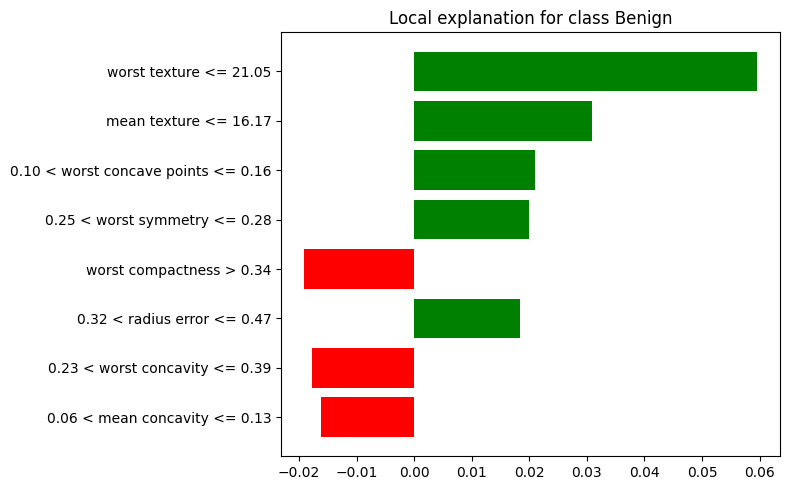

In [18]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Malignant', 'Benign'],
    mode='classification',
    random_state=42
)

# Wrap predict_proba so LIME's raw numpy rows are passed back to the model as a
# DataFrame with the original column names, avoiding sklearn's "missing feature names" warning
def predict_fn(data):
    return model_bc.predict_proba(pd.DataFrame(data, columns=X_train.columns))

lime_exp = lime_explainer.explain_instance(
    data_row=focus_instance_bc.iloc[0].values,
    predict_fn=predict_fn,
    num_features=8
)

print("LIME local explanation for Patient X (feature, weight toward Benign):")
for feat, weight in lime_exp.as_list():
    print(f"  {feat:35s} {weight:+.4f}")

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(8, 5)
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()


From the LIME bar chart, we can see that worst `texture <= 21.05` is by far the strongest driver toward Benign, agreeing with SHAP's top feature. Most of the other listed conditions are green (supporting Benign) as well, with `worst compactness`, `worst concavity`, and `mean concavity` being the only ones pushing red toward Malignant, which lines up with the mostly-benign-leaning picture from the SHAP plots above.

## SHAP vs LIME: Top 6 Features Compared ##

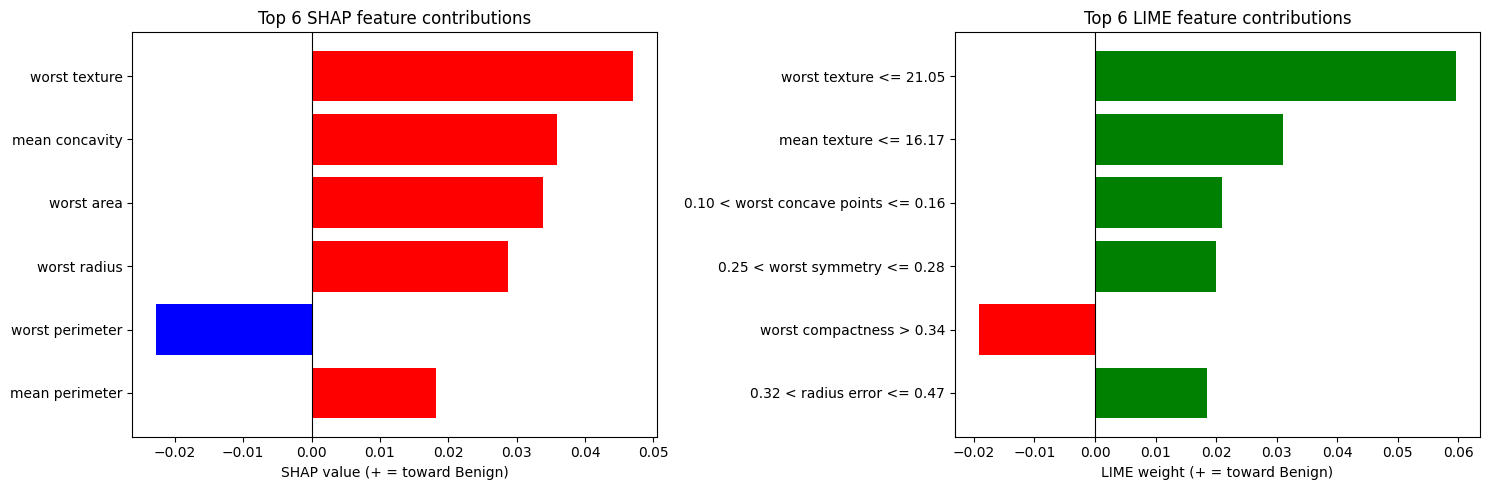

In [19]:
# Side-by-side: top 6 features by contribution size, for SHAP and LIME separately
top6_shap = sv_series.reindex(sv_series.abs().sort_values(ascending=False).index).head(6).iloc[::-1]
shap_colors = ['red' if v > 0 else 'blue' for v in top6_shap.values]

lime_sorted = sorted(lime_exp.as_list(), key=lambda x: abs(x[1]), reverse=True)[:6]
lime_features = [f for f, w in lime_sorted][::-1]
lime_weights = [w for f, w in lime_sorted][::-1]
lime_colors = ['green' if w > 0 else 'red' for w in lime_weights]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top6_shap.index, top6_shap.values, color=shap_colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 6 SHAP feature contributions')
axes[0].set_xlabel('SHAP value (+ = toward Benign)')

axes[1].barh(lime_features, lime_weights, color=lime_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 6 LIME feature contributions')
axes[1].set_xlabel('LIME weight (+ = toward Benign)')

plt.tight_layout()
plt.show()


Both agree worst texture is the dominant driver by a wide margin, and both agree it's overwhelmingly a Benign-leaning explanation with one dissenting feature each.

## Note: this arugument is based on the role I have (defense)

**Argument:** The model's prediction for Patient X was not arbitrary, the model followed the same logic the model learned from the broader dataset, and that logic is largely corroborated by two independent explanation methods.

- **Data trends (EDA):** Patient X's values for the model's 6 top-importance features fall within or close to the benign-class range for most features, not the malignant range, the boxplots above show Patient X's dashed line sitting closer to the Benign box for most of the top 6 features.
- **SHAP:** The SHAP force plot shows Patient X's probability moving from a 63% base rate (reflecting the ~63/37 benign/malignant split in the training data) up to 85% Benign, driven mainly by `worst texture`, `mean concavity`, `worst area`, and `worst radius`.
- **LIME:** The LIME local surrogate independently identifies `worst texture` as the single strongest driver toward Benign as well, agreement between two different explanation methods on the top feature strengthens the case that the model's reasoning was consistent rather than a fluke of one method's math.

In conclusion, both SHAP and LIME independently identify worst texture as the dominant driver, and both lean overwhelmingly toward Benign for Patient X, supporting the argument that the model's decision followed consistent, explainable logic rather than an error.
